In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 1
v0 = 0.01
V0 = v0 * 24 * np.pi * np.pi
beta = 0.01
deltaPhiWell = 2 * (2 / 3 * v0 / beta) ** (1 / 3)
phi0 = 0.5 * deltaPhiWell + 0.3 / np.sqrt(beta)

def infPotFunc(phi):
    x = phi - phi0
    return float(V0 * (1 + beta * x * x * x))

def infPotDerivFunc(phi):
    x = phi - phi0
    return float(3 * V0 * beta * x * x)

def infPotDeriv2Func(phi):
    x = phi - phi0
    return float(6 * V0 * beta * x)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

nGrid = 1024

# 1912.05399のbound
upperBound = phi0 + beta ** (-1 / 3)
lowerBound = 0

In [3]:
fpFinDiff_DirNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0"],
    ["Dirichlet"]
)

eigVals_DirNeu, eigVecs_DirNeu = np.linalg.eig(fpFinDiff_DirNeu)
eigVecsSort_DirNeu = eigVecs_DirNeu.T[np.argsort(eigVals_DirNeu)]
eigValsSort_DirNeu = np.sort(eigVals_DirNeu)

In [4]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

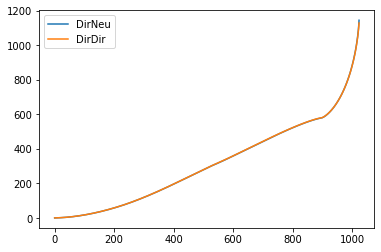

In [5]:
nMode = np.arange(nGrid)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

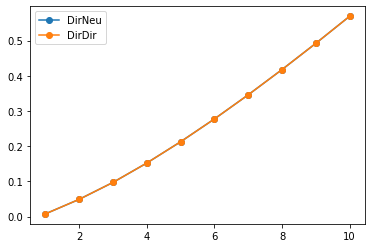

In [6]:
ax = plt.gca()
plt.plot(np.arange(1, 11), eigValsSort_DirNeu[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(1, 11), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [7]:
print(eigValsSort_DirNeu[:10])
print(eigValsSort_DirDir[:10])

[0.00738971 0.04874608 0.09683244 0.15192502 0.21236661 0.27722752
 0.3458314  0.41764711 0.49222971 0.56918629]
[0.00738971 0.04874609 0.09683244 0.15192504 0.21236664 0.27722757
 0.34583148 0.41764723 0.49222986 0.56918649]


「下端：ディリクレ、上端：ノイマン」と「下端：ディリクレ、上端：ノイマン」で、固有値ほぼ一致

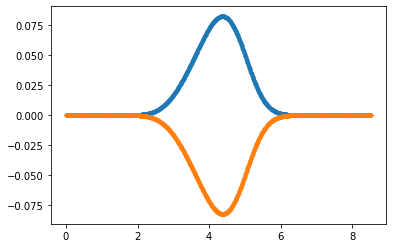

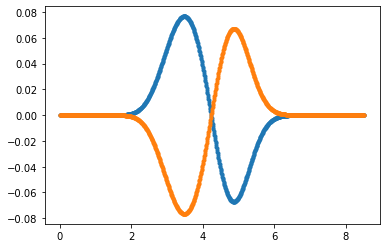

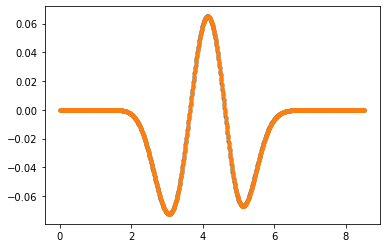

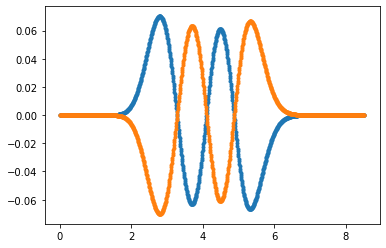

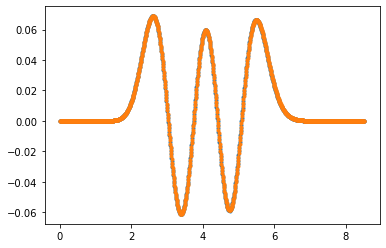

In [8]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))

ax = plt.gca()

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(grids, eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.show()

考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [9]:
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

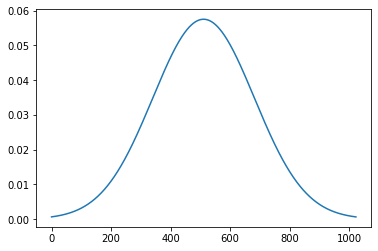

In [10]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

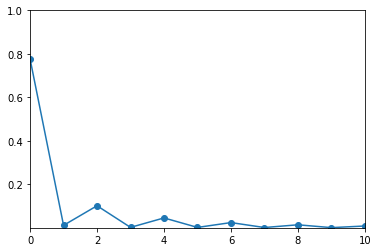

In [11]:
# 各固有ベクトルの寄与度
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort_DirDir]

ax = plt.gca()
plt.plot(nMode, contriEachEigVec, marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(1e-10, 1)
plt.show()

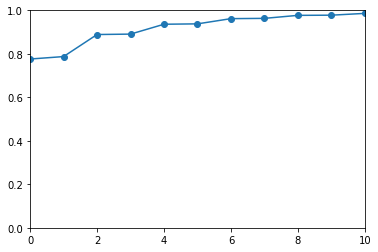

In [12]:
# 各固有ベクトルの寄与度（累積）
ax = plt.gca()
plt.plot(nMode, np.cumsum(contriEachEigVec), marker='o')
ax.set_xlim(0, 10)
ax.set_ylim(0, 1)
plt.show()

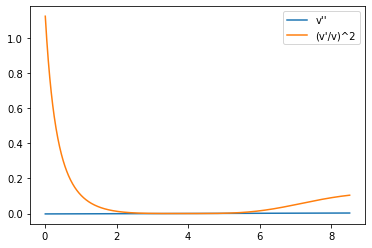

In [13]:
# v'' & (v'/v)^2
ax = plt.gca()
v = np.array([infPotFunc(g) for g in grids]) / (24 * np.pi ** 2)
vDer = np.array([infPotDerivFunc(g) for g in grids]) / (24 * np.pi ** 2)
vDer2 = np.array([infPotDeriv2Func(g) for g in grids]) / (24 * np.pi ** 2)
plt.plot(grids, vDer2, label="v''")
plt.plot(grids, (vDer / v) ** 2, label="(v'/v)^2")
plt.legend()
plt.show()

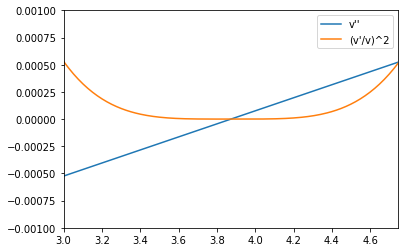

In [14]:
ax = plt.gca()
plt.plot(grids, vDer2, label="v''")
plt.plot(grids, (vDer / v) ** 2, label="(v'/v)^2")
plt.legend()
ax.set_xlim(phi0 - 0.5 * deltaPhiWell, phi0 + 0.5 * deltaPhiWell)
ax.set_ylim(-0.001, 0.001)
plt.show()